# Assignment 3

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import ToTensor, transforms
import matplotlib.pyplot as plt
import numpy as np

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import json

In [2]:
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Torch version: 2.10.0+cu128
CUDA version: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Using device: cuda


# 1. Loading dataset

### Loading CIFAR-10 dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [4]:
train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

### Split dataset in train and validation set - 80/20

In [5]:
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [7]:
print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))

40000
10000
10000


# 2. Three model architectures

### Baseline Lenet-5

In [8]:
class LeNet5(nn.Module):

    def __init__(self):
        super().__init__()
    
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x # cross entropy loss already applies log-softmax internally

### Lenet filters added

In [9]:
class LeNet5_Filters(nn.Module):

    def __init__(self):
        super().__init__()

        #increase the number of filters in the convolutional layers to 32 and 64 respectively
        self.conv1 = nn.Conv2d(3, 32, 5)
        self.pool = nn.MaxPool2d(2,2)
        
        self.conv2 = nn.Conv2d(32, 64, 5)

        self.fc1 = nn.Linear(64 * 5 * 5, 120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x # cross entropy loss already applies log-softmax internally

### Lenet filters + dropout

In [10]:
class LeNet5_Dropout(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 5)

        self.fc1 = nn.Linear(64*5*5,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

        #dropout layer with 0.5 dropout rate
        self.dropout = nn.Dropout(0.5)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x,1)

        #apply dropout after the first two fully connected layers
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))

        x = self.fc3(x)

        return x # cross entropy loss already applies log-softmax internally

# 3. Train models

In [11]:
criterion = nn.CrossEntropyLoss()

def train_epoch(model, train_loader, criterion, optimizer, device='cpu'):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / total, correct / total


def validate(model, val_loader, criterion, device='cpu'):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / total, correct / total

In [18]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=70):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    model.to(device)

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    history = {
        "train_loss": train_losses,
        "train_acc": train_accuracies,
        "val_loss": val_losses,
        "val_acc": val_accuracies
    }

    return model, history

In [ ]:
import os
import json
import torch

models = {
    "CIFAR10_lenet": LeNet5(),
    "CIFAR10_model1": LeNet5_Filters(),
    "CIFAR10_model2": LeNet5_Dropout()
}

history = {}

# create folders
os.makedirs("saved_models", exist_ok=True)
os.makedirs("saved_history", exist_ok=True)

for name, model in models.items():
    print(f"\nTraining {name}")

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    trained_model, hist = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=70
    )

    # save history in Python dict
    history[name] = hist

    # save model weights
    torch.save(trained_model.state_dict(), f"saved_models/{name}.pth")

    # save per-model history as JSON
    with open(f"saved_history/{name}_history.json", "w") as f:
        json.dump(hist, f, indent=4)

# save all histories together in one JSON file
with open("saved_history/all_histories.json", "w") as f:
    json.dump(history, f, indent=4)


Training CIFAR10_lenet
Epoch 1/70 | Train Loss: 1.6392 | Train Acc: 0.3989 | Val Loss: 1.4980 | Val Acc: 0.4585
Epoch 2/70 | Train Loss: 1.3557 | Train Acc: 0.5135 | Val Loss: 1.3205 | Val Acc: 0.5299
Epoch 3/70 | Train Loss: 1.2355 | Train Acc: 0.5560 | Val Loss: 1.2256 | Val Acc: 0.5611
Epoch 4/70 | Train Loss: 1.1460 | Train Acc: 0.5926 | Val Loss: 1.2170 | Val Acc: 0.5681
Epoch 5/70 | Train Loss: 1.0818 | Train Acc: 0.6148 | Val Loss: 1.1782 | Val Acc: 0.5837
Epoch 6/70 | Train Loss: 1.0215 | Train Acc: 0.6354 | Val Loss: 1.1635 | Val Acc: 0.5867
Epoch 7/70 | Train Loss: 0.9703 | Train Acc: 0.6543 | Val Loss: 1.1554 | Val Acc: 0.5941
Epoch 8/70 | Train Loss: 0.9243 | Train Acc: 0.6708 | Val Loss: 1.1756 | Val Acc: 0.5911
Epoch 9/70 | Train Loss: 0.8810 | Train Acc: 0.6864 | Val Loss: 1.1703 | Val Acc: 0.5926
Epoch 10/70 | Train Loss: 0.8407 | Train Acc: 0.7018 | Val Loss: 1.1851 | Val Acc: 0.5984
Epoch 11/70 | Train Loss: 0.8051 | Train Acc: 0.7146 | Val Loss: 1.2222 | Val Acc: 0.

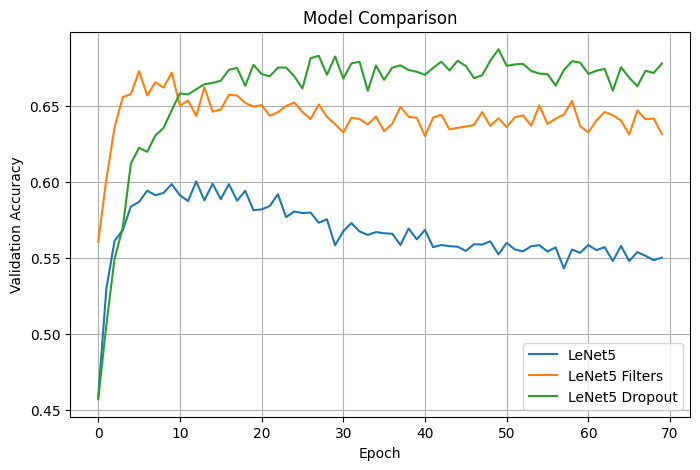

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history['CIFAR10_lenet']['val_acc'], label="LeNet5")
plt.plot(history['CIFAR10_model1']['val_acc'], label="LeNet5 Filters")
plt.plot(history['CIFAR10_model2']['val_acc'], label="LeNet5 Dropout")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.legend()
plt.grid(True)
plt.show()

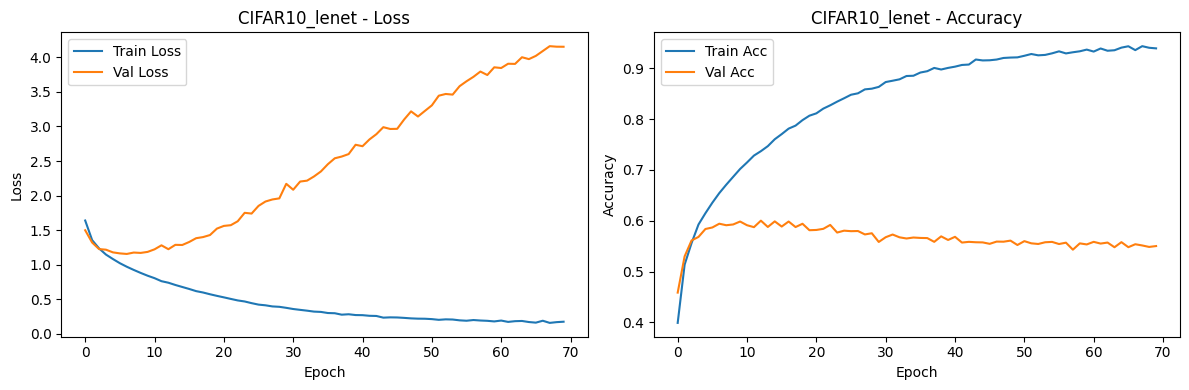

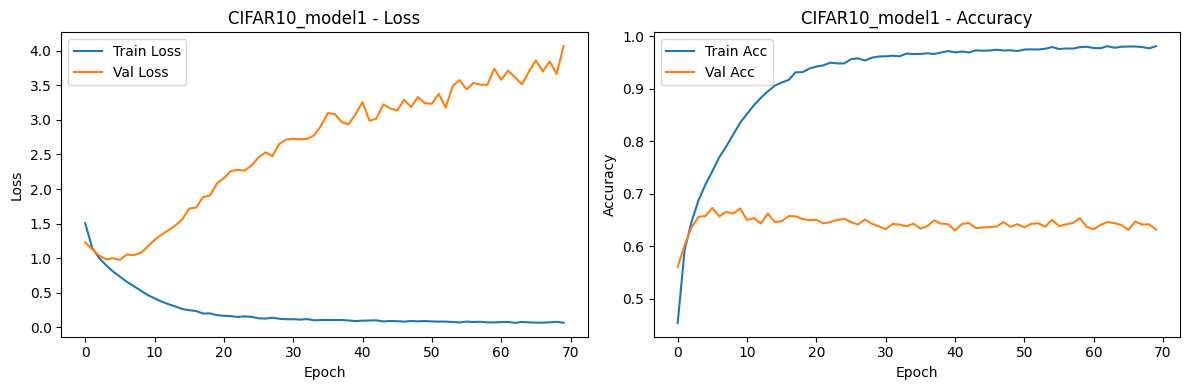

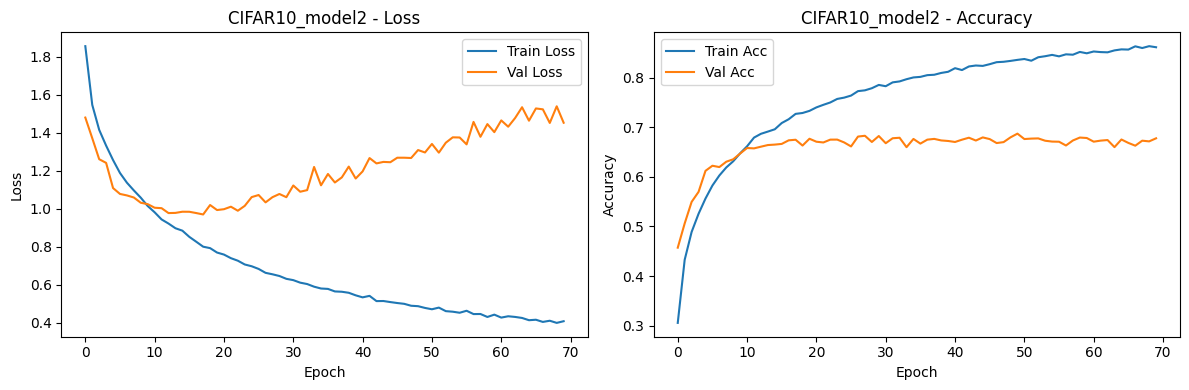

In [25]:
for model_name, data in history.items():
    plt.figure(figsize=(12, 4))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(data['train_loss'], label='Train Loss')
    plt.plot(data['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(data['train_acc'], label='Train Acc')
    plt.plot(data['val_acc'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# 4. Choose best architecture and load CIFAR-100

### LeNet5_Filters is the best architecture

In [26]:
best_model_name = max(history, key=lambda x: max(history[x]['val_acc']))
print("Best architecture:", best_model_name)

Best architecture: CIFAR10_model2


### Loading CIFAR100 dataset

In [31]:
train_data = datasets.CIFAR100(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR100(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100.0%


In [32]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader_100 = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_100 = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [33]:
class CIFAR100_Model(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 5)

        self.fc1 = nn.Linear(64 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 20)   # changed from 10 to 20

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [ ]:
CIFAR100_model = CIFAR100_Model().to(device)

optimizer = torch.optim.Adam(CIFAR100_model.parameters(), lr=0.001)

CIFAR100_model, history_100 = train_model(
    CIFAR100_model,
    train_loader_100,
    val_loader_100,
    criterion,
    optimizer,
    device,
    epochs=70
)

torch.save(CIFAR100_model.state_dict(), f"saved_models/CIFAR100_model.pth")

# save all histories together in one JSON file
with open("saved_history/CIFAR100_model.json", "w") as f:
    json.dump(history_100, f, indent=4)


Epoch 1/70 | Train Loss: 1.5695 | Train Acc: 0.4310 | Val Loss: 1.3105 | Val Acc: 0.5242
Epoch 2/70 | Train Loss: 1.2012 | Train Acc: 0.5761 | Val Loss: 1.1763 | Val Acc: 0.5988
Epoch 3/70 | Train Loss: 1.0535 | Train Acc: 0.6317 | Val Loss: 1.0862 | Val Acc: 0.6212
Epoch 4/70 | Train Loss: 0.9458 | Train Acc: 0.6677 | Val Loss: 1.0461 | Val Acc: 0.6376
Epoch 5/70 | Train Loss: 0.8489 | Train Acc: 0.7022 | Val Loss: 1.1009 | Val Acc: 0.6135
Epoch 6/70 | Train Loss: 0.7813 | Train Acc: 0.7249 | Val Loss: 0.9889 | Val Acc: 0.6633
Epoch 7/70 | Train Loss: 0.7049 | Train Acc: 0.7532 | Val Loss: 1.0197 | Val Acc: 0.6599
Epoch 8/70 | Train Loss: 0.6442 | Train Acc: 0.7760 | Val Loss: 1.0426 | Val Acc: 0.6573
Epoch 9/70 | Train Loss: 0.5781 | Train Acc: 0.7970 | Val Loss: 1.1076 | Val Acc: 0.6532
Epoch 10/70 | Train Loss: 0.5251 | Train Acc: 0.8159 | Val Loss: 1.1859 | Val Acc: 0.6485
Epoch 11/70 | Train Loss: 0.4752 | Train Acc: 0.8326 | Val Loss: 1.2158 | Val Acc: 0.6479
Epoch 12/70 | Train

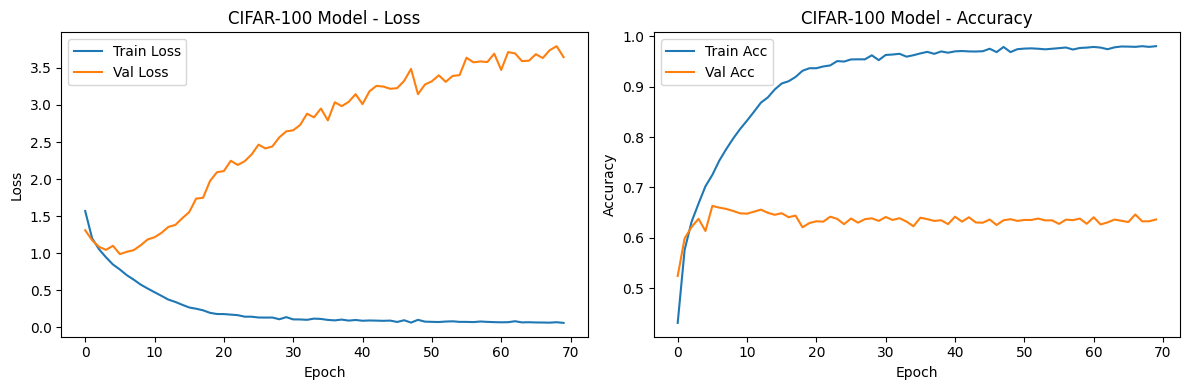

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_100['train_loss'], label='Train Loss')
plt.plot(history_100['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CIFAR-100 Model - Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_100['train_acc'], label='Train Acc')
plt.plot(history_100['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CIFAR-100 Model - Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 5. Use CIFAR100_model and change layer.

### Layer back to 10 outputs. Keep weights the same. 

In [ ]:
import copy
import torch
import torch.nn as nn

# Start from the trained CIFAR-100 model
CIFAR10_pretrained = copy.deepcopy(CIFAR100_model)

# Replace only the final layer: 20 -> 10 outputs
CIFAR10_pretrained.fc3 = nn.Linear(84, 10)

# Initialize the new last layer
nn.init.kaiming_uniform_(CIFAR10_pretrained.fc3.weight, nonlinearity='relu')
if CIFAR10_pretrained.fc3.bias is not None:
    nn.init.zeros_(CIFAR10_pretrained.fc3.bias)

# Move to device
CIFAR10_pretrained = CIFAR10_pretrained.to(device)

# Fine-tune with half the original learning rate
optimizer_pretrained = torch.optim.Adam(CIFAR10_pretrained.parameters(), lr=0.0005)

# Train on CIFAR-10
CIFAR10_pretrained, history_pretrained = train_model(
    CIFAR10_pretrained,
    train_loader,
    val_loader,
    criterion,
    optimizer_pretrained,
    device,
    epochs=70
)

torch.save(CIFAR10_pretrained.state_dict(), f"saved_models/CIFAR10_pretrained.pth")

# save all histories together in one JSON file
with open("saved_history/CIFAR10_pretrained.json", "w") as f:
    json.dump(history_pretrained, f, indent=4)




Epoch 1/70 | Train Loss: 1.8464 | Train Acc: 0.4526 | Val Loss: 1.3310 | Val Acc: 0.5893
Epoch 2/70 | Train Loss: 0.6426 | Train Acc: 0.8060 | Val Loss: 1.3654 | Val Acc: 0.6521
Epoch 3/70 | Train Loss: 0.3545 | Train Acc: 0.9015 | Val Loss: 1.3624 | Val Acc: 0.6603
Epoch 4/70 | Train Loss: 0.2509 | Train Acc: 0.9313 | Val Loss: 1.4775 | Val Acc: 0.6636
Epoch 5/70 | Train Loss: 0.1858 | Train Acc: 0.9503 | Val Loss: 1.5683 | Val Acc: 0.6664
Epoch 6/70 | Train Loss: 0.1409 | Train Acc: 0.9623 | Val Loss: 1.7079 | Val Acc: 0.6609
Epoch 7/70 | Train Loss: 0.1067 | Train Acc: 0.9709 | Val Loss: 1.8520 | Val Acc: 0.6677
Epoch 8/70 | Train Loss: 0.0823 | Train Acc: 0.9774 | Val Loss: 2.0401 | Val Acc: 0.6618
Epoch 9/70 | Train Loss: 0.0596 | Train Acc: 0.9830 | Val Loss: 2.2378 | Val Acc: 0.6556
Epoch 10/70 | Train Loss: 0.0503 | Train Acc: 0.9855 | Val Loss: 2.4562 | Val Acc: 0.6508
Epoch 11/70 | Train Loss: 0.0432 | Train Acc: 0.9874 | Val Loss: 2.5070 | Val Acc: 0.6556
Epoch 12/70 | Train

# 6. Compare CIFAR-10 model and CIFAR10_pretrained model on test set. 

### Evaluate code

In [37]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

def evaluate_on_test(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, cm

### Evaluate both models

Replace best_model with whichever of your three CIFAR-10 models had the best validation performance.

In [38]:
best_model = models["CIFAR10_model1"]   # example, change if needed

best_test_acc, best_cm = evaluate_on_test(best_model, test_loader, device)
pretrained_test_acc, pretrained_cm = evaluate_on_test(CIFAR10_pretrained, test_loader, device)

print(f"Best CIFAR-10 model test accuracy: {best_test_acc:.4f}")
print(f"CIFAR10_pretrained test accuracy: {pretrained_test_acc:.4f}")

Best CIFAR-10 model test accuracy: 0.6295
CIFAR10_pretrained test accuracy: 0.6457


### Plot Confusion Matrices

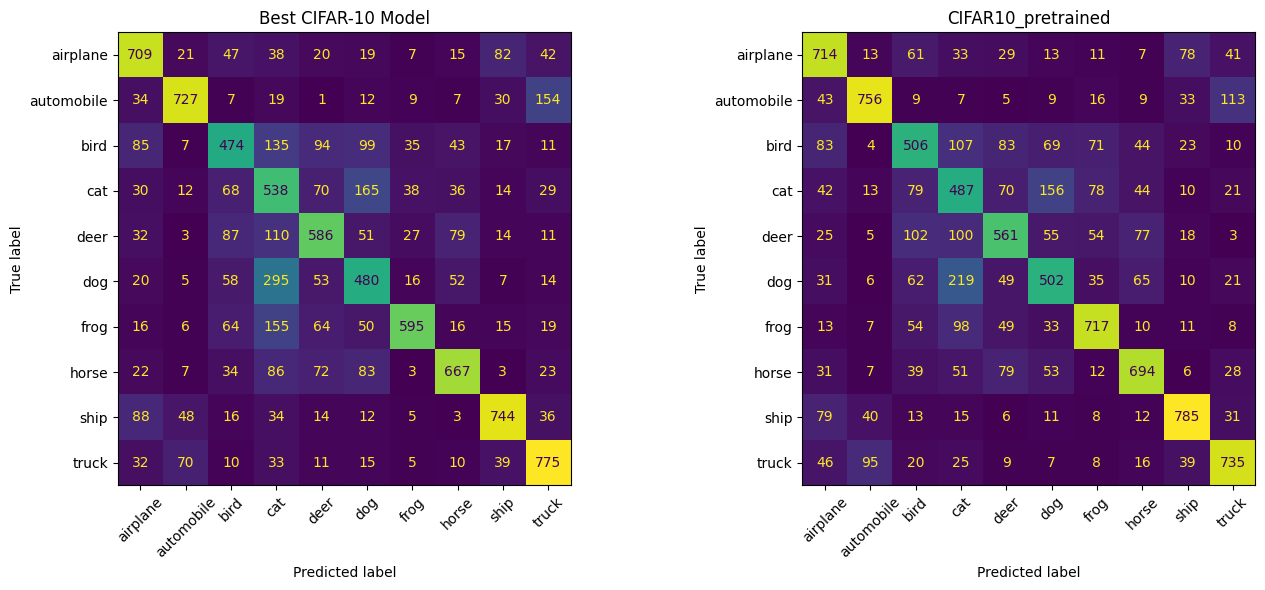

In [39]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp1 = ConfusionMatrixDisplay(confusion_matrix=best_cm, display_labels=class_names)
disp1.plot(ax=axes[0], xticks_rotation=45, colorbar=False)
axes[0].set_title("Best CIFAR-10 Model")

disp2 = ConfusionMatrixDisplay(confusion_matrix=pretrained_cm, display_labels=class_names)
disp2.plot(ax=axes[1], xticks_rotation=45, colorbar=False)
axes[1].set_title("CIFAR10_pretrained")

plt.tight_layout()
plt.show()

### Report results in table

In [40]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Best CIFAR-10 model", "CIFAR10_pretrained"],
    "Test Accuracy": [best_test_acc, pretrained_test_acc]
})

print(results_df)

                 Model  Test Accuracy
0  Best CIFAR-10 model         0.6295
1   CIFAR10_pretrained         0.6457


# 7. Choices 

### EarlyStopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False
        
        self.best_weights = None

    def __call__(self, val_loss, model):
        
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            
            # store best weights in memory
            self.best_weights = model.state_dict()
        
        else:
            self.counter += 1
            
            if self.counter >= self.patience:
                self.early_stop = True

### Choice 1 - Decrease learning rate

In [41]:
def step_lr_decay(initial_lr, epoch, step_size=5, decay_factor=0.5):
    return initial_lr * (decay_factor ** (epoch // step_size))

In [42]:
def train_model2(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=70,
    use_scheduler=False,
    initial_lr=0.001
):

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    lr_history = []

    model.to(device)

    for epoch in range(epochs):

        # learning rate scheduling
        if use_scheduler:
            lr = step_lr_decay(initial_lr, epoch)
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
        else:
            lr = optimizer.param_groups[0]["lr"]

        lr_history.append(lr)

        # training
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # validation
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"LR: {lr:.6f} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    history = {
        "train_loss": train_losses,
        "train_acc": train_accuracies,
        "val_loss": val_losses,
        "val_acc": val_accuracies,
        "lr_history": lr_history
    }

    return model, history

In [ ]:
# Baseline no scheduler

model_base, hist_base = train_model2(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    use_scheduler=False
)

torch.save(model_base.state_dict(), f"saved_models/choice1_model_base.pth")

# save all histories together in one JSON file
with open("saved_history/choice_1_hist_base.json", "w") as f:
    json.dump(hist_base, f, indent=4)


Epoch 1/70 | LR: 0.001000 | Train Loss: 0.3504 | Train Acc: 0.8769 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 2/70 | LR: 0.001000 | Train Loss: 0.3556 | Train Acc: 0.8782 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 3/70 | LR: 0.001000 | Train Loss: 0.3547 | Train Acc: 0.8769 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 4/70 | LR: 0.001000 | Train Loss: 0.3518 | Train Acc: 0.8777 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 5/70 | LR: 0.001000 | Train Loss: 0.3551 | Train Acc: 0.8761 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 6/70 | LR: 0.001000 | Train Loss: 0.3529 | Train Acc: 0.8782 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 7/70 | LR: 0.001000 | Train Loss: 0.3509 | Train Acc: 0.8783 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 8/70 | LR: 0.001000 | Train Loss: 0.3532 | Train Acc: 0.8767 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 9/70 | LR: 0.001000 | Train Loss: 0.3528 | Train Acc: 0.8776 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 10/70 | LR: 0.001000 | Train Loss: 0.3539 | Train Acc: 0.8

In [ ]:
# With LR decay

model_sched, hist_sched = train_model2(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    use_scheduler=True,
    initial_lr=0.001
)

torch.save(model_sched.state_dict(), f"saved_models/choice1_model_sched.pth")

# save all histories together in one JSON file
with open("saved_history/choice_1_hist_sched.json", "w") as f:
    json.dump(hist_sched, f, indent=4)

Epoch 1/70 | LR: 0.001000 | Train Loss: 0.3498 | Train Acc: 0.8783 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 2/70 | LR: 0.001000 | Train Loss: 0.3540 | Train Acc: 0.8776 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 3/70 | LR: 0.001000 | Train Loss: 0.3578 | Train Acc: 0.8745 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 4/70 | LR: 0.001000 | Train Loss: 0.3585 | Train Acc: 0.8756 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 5/70 | LR: 0.001000 | Train Loss: 0.3488 | Train Acc: 0.8783 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 6/70 | LR: 0.000500 | Train Loss: 0.3512 | Train Acc: 0.8777 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 7/70 | LR: 0.000500 | Train Loss: 0.3509 | Train Acc: 0.8794 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 8/70 | LR: 0.000500 | Train Loss: 0.3535 | Train Acc: 0.8759 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 9/70 | LR: 0.000500 | Train Loss: 0.3566 | Train Acc: 0.8770 | Val Loss: 1.4522 | Val Acc: 0.6776
Epoch 10/70 | LR: 0.000500 | Train Loss: 0.3471 | Train Acc: 0.8

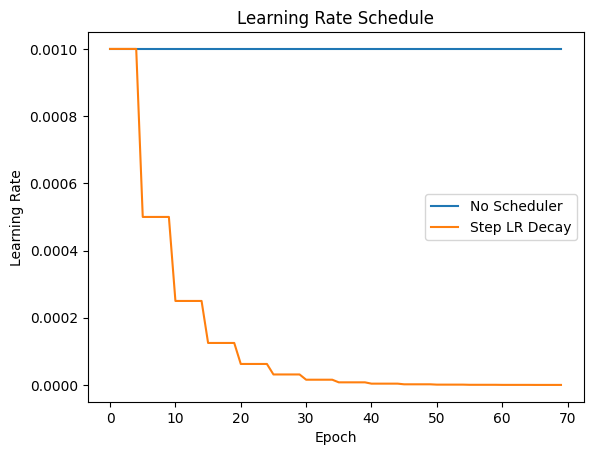

In [46]:
plt.plot(hist_base["lr_history"], label="No Scheduler")
plt.plot(hist_sched["lr_history"], label="Step LR Decay")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.legend()
plt.show()

### Choice 2 - k-fold cross-validation

Load CIFAR_10 training set

In [47]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

K-fold training function

In [ ]:
import numpy as np
import torch
import json
import os
from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader

def k_fold_cross_validation(
    model_class,
    dataset,
    criterion,
    device,
    k=5,
    epochs=70,
    batch_size=32,
    lr=0.001,
    random_state=42
):
    os.makedirs("saved_models", exist_ok=True)
    os.makedirs("saved_history", exist_ok=True)

    kfold = KFold(n_splits=k, shuffle=True, random_state=random_state)

    fold_results = []
    fold_histories = []

    indices = np.arange(len(dataset))

    for fold, (train_idx, val_idx) in enumerate(kfold.split(indices)):
        print(f"\n===== Fold {fold+1}/{k} =====")

        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

        model = model_class().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        model, history = train_model(
            model,
            train_loader,
            val_loader,
            criterion,
            optimizer,
            device,
            epochs=epochs
        )

        best_val_acc = max(history["val_acc"])
        best_val_loss = min(history["val_loss"])

        fold_results.append({
            "fold": fold + 1,
            "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss
        })

        fold_histories.append(history)

        print(
            f"Fold {fold+1} finished | "
            f"Best Val Acc: {best_val_acc:.4f} | "
            f"Best Val Loss: {best_val_loss:.4f}"
        )

        # save model
        torch.save(model.state_dict(), f"saved_models/choice_2_model_fold{fold+1}.pth")

        # save history
        json.dump(
            {key: [float(x) for x in value] for key, value in history.items()},
            open(f"saved_history/choice_2_history_fold{fold+1}.json", "w")
        )

    # save summary results
    json.dump(fold_results, open("saved_history/choice_2_fold_results.json", "w"), indent=4)

    json.dump(
        [{key: [float(x) for x in value] for key, value in h.items()} for h in fold_histories],
        open("saved_history/choice_2_all_fold_histories.json", "w")
    )

    return fold_results, fold_histories

Run 5-fold cross-validation

In [ ]:
criterion = torch.nn.CrossEntropyLoss()

cv_results, cv_histories = k_fold_cross_validation(
    model_class=LeNet5_Filters,
    dataset=full_train_dataset,
    criterion=criterion,
    device=device,
    k=5,
    epochs=70,
    batch_size=32,
    lr=0.001
)




===== Fold 1/5 =====
Epoch 1/70 | Train Loss: 1.4746 | Train Acc: 0.4661 | Val Loss: 1.2222 | Val Acc: 0.5699
Epoch 2/70 | Train Loss: 1.1070 | Train Acc: 0.6068 | Val Loss: 1.1420 | Val Acc: 0.6004
Epoch 3/70 | Train Loss: 0.9566 | Train Acc: 0.6628 | Val Loss: 1.0278 | Val Acc: 0.6446
Epoch 4/70 | Train Loss: 0.8527 | Train Acc: 0.7006 | Val Loss: 1.0040 | Val Acc: 0.6500
Epoch 5/70 | Train Loss: 0.7626 | Train Acc: 0.7320 | Val Loss: 1.0120 | Val Acc: 0.6557
Epoch 6/70 | Train Loss: 0.6801 | Train Acc: 0.7601 | Val Loss: 1.0238 | Val Acc: 0.6560
Epoch 7/70 | Train Loss: 0.6067 | Train Acc: 0.7851 | Val Loss: 0.9892 | Val Acc: 0.6785
Epoch 8/70 | Train Loss: 0.5390 | Train Acc: 0.8097 | Val Loss: 1.0631 | Val Acc: 0.6710
Epoch 9/70 | Train Loss: 0.4802 | Train Acc: 0.8328 | Val Loss: 1.0850 | Val Acc: 0.6719
Epoch 10/70 | Train Loss: 0.4103 | Train Acc: 0.8564 | Val Loss: 1.1792 | Val Acc: 0.6640
Epoch 11/70 | Train Loss: 0.3700 | Train Acc: 0.8710 | Val Loss: 1.2322 | Val Acc: 0.66

Summarize fold results

In [50]:
import pandas as pd

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

mean_val_acc = cv_results_df["best_val_acc"].mean()
std_val_acc = cv_results_df["best_val_acc"].std()

mean_val_loss = cv_results_df["best_val_loss"].mean()
std_val_loss = cv_results_df["best_val_loss"].std()

print(f"\nMean Best Validation Accuracy: {mean_val_acc:.4f} ± {std_val_acc:.4f}")
print(f"Mean Best Validation Loss: {mean_val_loss:.4f} ± {std_val_loss:.4f}")

   fold  best_val_acc  best_val_loss
0     1        0.6785       0.989247
1     2        0.6604       1.041750
2     3        0.6827       0.992209
3     4        0.6688       0.963133
4     5        0.6723       0.952117

Mean Best Validation Accuracy: 0.6725 ± 0.0087
Mean Best Validation Loss: 0.9877 ± 0.0347


Compare against fixed train/validation split

In [51]:
history_fixed = history["CIFAR10_model2"]

In [52]:
fixed_best_val_acc = max(history_fixed["val_acc"])
fixed_best_val_loss = min(history_fixed["val_loss"])

comparison_df = pd.DataFrame({
    "Method": ["Fixed Train/Val Split", "5-Fold Cross-Validation"],
    "Validation Accuracy": [fixed_best_val_acc, mean_val_acc],
    "Validation Loss": [fixed_best_val_loss, mean_val_loss]
})

print(comparison_df)

                    Method  Validation Accuracy  Validation Loss
0    Fixed Train/Val Split              0.68700         0.969424
1  5-Fold Cross-Validation              0.67254         0.987691


Plot validation accuracy per fold

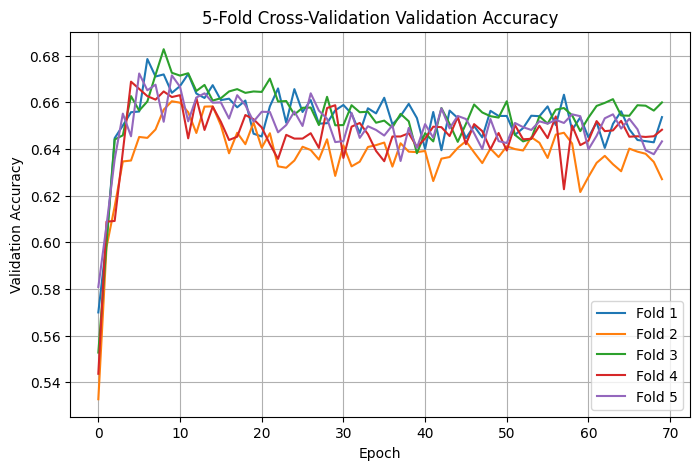

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for i, hist in enumerate(cv_histories):
    plt.plot(hist["val_acc"], label=f"Fold {i+1}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("5-Fold Cross-Validation Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Plot average validation accuracy across folds

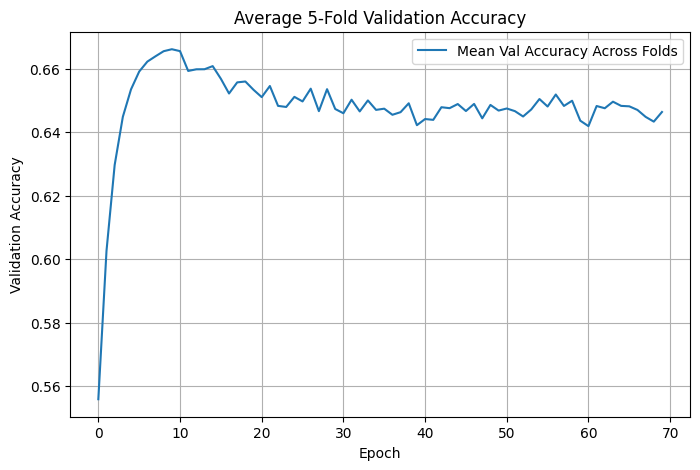

In [54]:
val_acc_matrix = np.array([hist["val_acc"] for hist in cv_histories])
mean_val_acc_per_epoch = val_acc_matrix.mean(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(mean_val_acc_per_epoch, label="Mean Val Accuracy Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Average 5-Fold Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Full minimal version in one block, if the above code doesn't work

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

def k_fold_cross_validation(
    model_class,
    dataset,
    criterion,
    device,
    k=5,
    epochs=70,
    batch_size=32,
    lr=0.001,
    random_state=42
):
    kfold = KFold(n_splits=k, shuffle=True, random_state=random_state)
    fold_results = []
    fold_histories = []

    indices = np.arange(len(dataset))

    for fold, (train_idx, val_idx) in enumerate(kfold.split(indices)):
        print(f"\n===== Fold {fold+1}/{k} =====")

        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

        model = model_class().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        model, history = train_model(
            model,
            train_loader,
            val_loader,
            criterion,
            optimizer,
            device,
            epochs=epochs
        )

        best_val_acc = max(history["val_acc"])
        best_val_loss = min(history["val_loss"])

        fold_results.append({
            "fold": fold + 1,
            "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss
        })

        fold_histories.append(history)

        print(
            f"Fold {fold+1} finished | "
            f"Best Val Acc: {best_val_acc:.4f} | "
            f"Best Val Loss: {best_val_loss:.4f}"
        )

    return fold_results, fold_histories

criterion = torch.nn.CrossEntropyLoss()

cv_results, cv_histories = k_fold_cross_validation(
    model_class=LeNet5,
    dataset=full_train_dataset,
    criterion=criterion,
    device=device,
    k=5,
    epochs=70,
    batch_size=32,
    lr=0.001
)

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

mean_val_acc = cv_results_df["best_val_acc"].mean()
std_val_acc = cv_results_df["best_val_acc"].std()

print(f"\nMean Best Validation Accuracy: {mean_val_acc:.4f} ± {std_val_acc:.4f}")

plt.figure(figsize=(8, 5))
for i, hist in enumerate(cv_histories):
    plt.plot(hist["val_acc"], label=f"Fold {i+1}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("5-Fold Cross-Validation Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Choice 6 - t-SNE

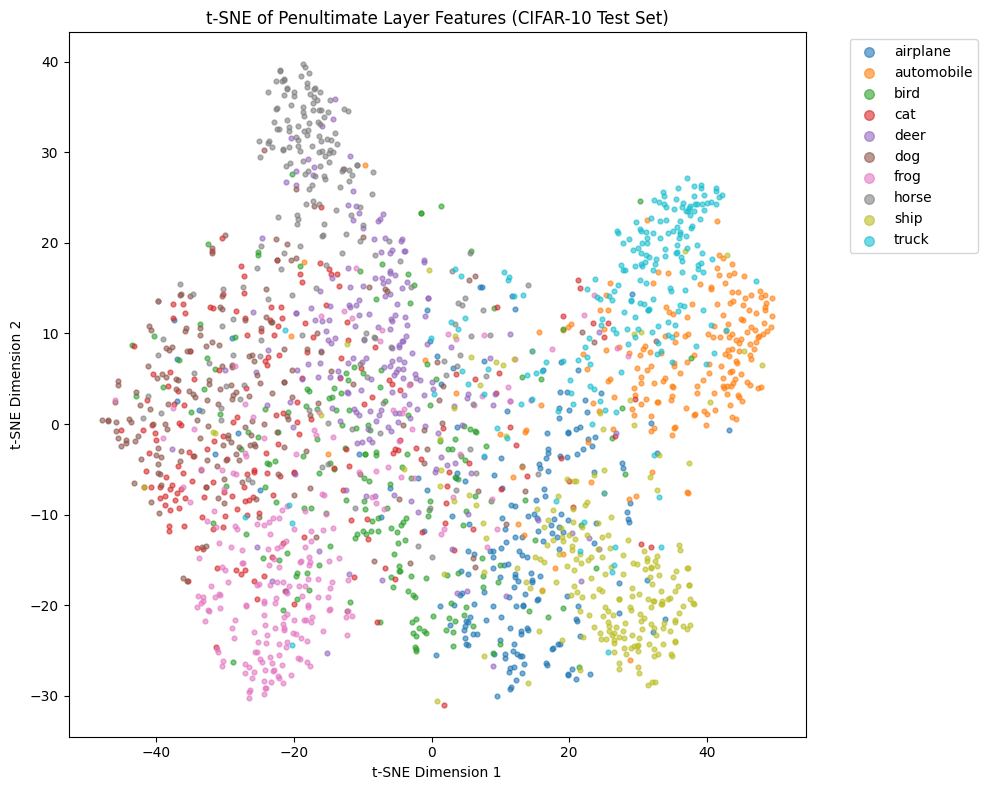

In [55]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def extract_penultimate_features_subset(model, data_loader, device, max_samples=2000):
    model.eval()
    features = []
    labels_list = []
    collected = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            x = model.pool(F.relu(model.conv1(images)))
            x = model.pool(F.relu(model.conv2(x)))
            x = torch.flatten(x, 1)
            x = F.relu(model.fc1(x))
            x = F.relu(model.fc2(x))

            batch_features = x.cpu().numpy()
            batch_labels = labels.cpu().numpy()

            remaining = max_samples - collected
            if remaining <= 0:
                break

            batch_features = batch_features[:remaining]
            batch_labels = batch_labels[:remaining]

            features.append(batch_features)
            labels_list.append(batch_labels)
            collected += len(batch_features)

    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    return features, labels

# Choose one of your best models
chosen_model = best_model

features, labels = extract_penultimate_features_subset(
    chosen_model, test_loader, device, max_samples=2000
)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

features_2d = tsne.fit_transform(features)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(10, 8))

for class_idx, class_name in enumerate(class_names):
    idxs = labels == class_idx
    plt.scatter(
        features_2d[idxs, 0],
        features_2d[idxs, 1],
        label=class_name,
        alpha=0.6,
        s=12
    )

plt.title("t-SNE of Penultimate Layer Features (CIFAR-10 Test Set)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()